# Module M1.2 — Column Removal & Feature Set Finalization

**Project:** Explainable and Bias-Aware ML for Phishing Website Detection  
**Roadmap ref:** Phase 1 → Module M1.2  

### Objectives
1. Load `data/processed/clean_df.csv` from M1.1  
2. Identify and drop identifier columns (FILENAME, URL, Domain, Title)  
3. Identify and drop multicollinear column (URLTitleMatchScore, r=0.961)  
4. Prove URLSimilarityIndex leakage and define Track A / Track B  
5. Compute full feature-feature correlation matrix  
6. Audit near-constant and high-skewness features  
7. Run mutual-information pre-screening  
8. Generate all EDA visualisations  
9. Produce `outputs/reports/m1_2_feature_finalization_report.html`  
10. Save approved feature lists to `config/feature_config.yaml`  


## 0. Environment Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import yaml

from sklearn.feature_selection import mutual_info_classif

from src.utils.logger              import get_logger
from src.features.feature_catalog  import (
    get_feature_lists, run_feature_audit,
    apply_column_removal, build_feature_audit_table,
    compute_pairwise_correlations, compute_variance_stats,
    compute_skewness, compute_correlation_with_target,
    DROP_IDENTIFIERS, DROP_MULTICOLLINEAR, DROP_ALL,
    LEAKAGE_CRITICAL, LEAKAGE_ADVISORY,
    TRACK_A_FEATURES, TRACK_B_FEATURES,
    FEATURE_CATEGORIES, TARGET_COLUMN,
)
from src.features.report_m1_2 import generate_report

logger = get_logger('notebook.02_feature_finalization')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 130

print('Imports OK')


Imports OK


## 1. Path Configuration

In [3]:
CLEAN_CSV   = PROJECT_ROOT / 'data' / 'processed' / 'clean_df.csv'
REPORT_DIR  = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_EDA   = PROJECT_ROOT / 'outputs' / 'plots' / 'eda'
CONFIG_PATH = PROJECT_ROOT / 'config' / 'feature_config.yaml'

assert CLEAN_CSV.exists(), f'clean_df.csv not found — run M1.1 first: {CLEAN_CSV}'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_EDA.mkdir(parents=True, exist_ok=True)

print(f'Clean CSV   : {CLEAN_CSV}')
print(f'Report dir  : {REPORT_DIR}')
print(f'Plots dir   : {PLOTS_EDA}')


Clean CSV   : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\data\processed\clean_df.csv
Report dir  : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports
Plots dir   : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\plots\eda


## 2. Load clean_df.csv

In [4]:
df = pd.read_csv(CLEAN_CSV, low_memory=False)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
display(df.head(3))


Loaded: 235,370 rows × 56 columns


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1


## 3. Feature Lists — Single Source of Truth

In [5]:
fl = get_feature_lists()

print(f'Identifiers to drop    : {fl.drop_identifiers}')
print(f'Multicollinear to drop : {fl.drop_multicollinear}')
print(f'Leakage critical       : {fl.leakage_critical}')
print(f'Leakage advisory       : {fl.leakage_advisory}')
print(f'Track A features       : {len(fl.track_A)}')
print(f'Track B features       : {len(fl.track_B)}')


Identifiers to drop    : ['FILENAME', 'URL', 'Domain', 'Title']
Multicollinear to drop : ['URLTitleMatchScore']
Leakage critical       : ['URLSimilarityIndex']
Leakage advisory       : ['IsHTTPS']
Track A features       : 50
Track B features       : 49


In [6]:
print('=== Track B Features (49) ===')
for i, f in enumerate(fl.track_B, 1):
    cat = next((c for c, feats in fl.categories.items() if f in feats), '—')
    print(f'  {i:2}. {f:<38} [{cat}]')


=== Track B Features (49) ===
   1. URLLength                              [URL Structure]
   2. DomainLength                           [URL Structure]
   3. TLDLength                              [URL Structure]
   4. TLD                                    [URL Structure]
   5. IsDomainIP                             [URL Structure]
   6. NoOfSubDomain                          [URL Structure]
   7. IsHTTPS                                [URL Structure]
   8. CharContinuationRate                   [URL Statistical]
   9. TLDLegitimateProb                      [URL Statistical]
  10. URLCharProb                            [URL Statistical]
  11. NoOfLettersInURL                       [URL Character Composition]
  12. LetterRatioInURL                       [URL Character Composition]
  13. NoOfDegitsInURL                        [URL Character Composition]
  14. DegitRatioInURL                        [URL Character Composition]
  15. NoOfEqualsInURL                        [URL Character Co

## 4. Column Removal — Identifiers & Multicollinear

In [7]:
print('--- Identifier columns ---')
for c in fl.drop_identifiers:
    print(f'  {c:<20} dtype={df[c].dtype}  nunique={df[c].nunique():,}')

print('\n--- Multicollinear column ---')
if 'URLTitleMatchScore' in df.columns and 'DomainTitleMatchScore' in df.columns:
    r = df[['URLTitleMatchScore','DomainTitleMatchScore']].corr().iloc[0,1]
    print(f'  URLTitleMatchScore <-> DomainTitleMatchScore: r={r:.6f}')
    print(f'  Decision: DROP URLTitleMatchScore (highest corr, less informative name)')


--- Identifier columns ---
  FILENAME             dtype=str  nunique=235,370
  URL                  dtype=str  nunique=235,370
  Domain               dtype=str  nunique=220,086
  Title                dtype=str  nunique=197,782

--- Multicollinear column ---
  URLTitleMatchScore <-> DomainTitleMatchScore: r=0.961166
  Decision: DROP URLTitleMatchScore (highest corr, less informative name)


In [8]:
# Apply Track B column removal
df_B = apply_column_removal(df, track='B')
df_A = apply_column_removal(df, track='A')

print(f'Original shape : {df.shape}')
print(f'Track A shape  : {df_A.shape}  (50 features + label)')
print(f'Track B shape  : {df_B.shape}  (49 features + label)')

assert df_B.shape[1] == 50, f'Expected 50 cols (49 features + label), got {df_B.shape[1]}'
assert df_A.shape[1] == 51, f'Expected 51 cols (50 features + label), got {df_A.shape[1]}'
print('Shape validation PASSED ✓')


2026-06-17 16:57:43 | INFO     | src.features.feature_catalog             | Track B: 49 features + target → 50 columns total
2026-06-17 16:57:43 | INFO     | src.features.feature_catalog             | Track A: 50 features + target → 51 columns total


Original shape : (235370, 56)
Track A shape  : (235370, 51)  (50 features + label)
Track B shape  : (235370, 50)  (49 features + label)
Shape validation PASSED ✓


## 5. Leakage Analysis — URLSimilarityIndex

In [9]:
# Prove leakage: URLSimilarityIndex == 100.0 for ALL label=1
usi_by_label = df.groupby(TARGET_COLUMN)['URLSimilarityIndex'].describe()
print('URLSimilarityIndex statistics by label:')
display(usi_by_label)

all_legit_100 = (df[df[TARGET_COLUMN]==1]['URLSimilarityIndex'] == 100).all()
any_legit_not = (df[df[TARGET_COLUMN]==1]['URLSimilarityIndex'] != 100).any()

print(f'\nAll legitimate records have URLSimilarityIndex=100 : {all_legit_100}')
print(f'Any legitimate record with value != 100           : {any_legit_not}')
assert all_legit_100, 'Leakage assumption violated — recheck dataset'
print('Leakage CONFIRMED: URLSimilarityIndex encodes the label ✓')


URLSimilarityIndex statistics by label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,49.651466,22.578566,0.155574,32.120613,51.478561,67.307692,100.0
1,134850.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.0



All legitimate records have URLSimilarityIndex=100 : True
Any legitimate record with value != 100           : False
Leakage CONFIRMED: URLSimilarityIndex encodes the label ✓


findfont: Failed to find font weight 600, now using 700.


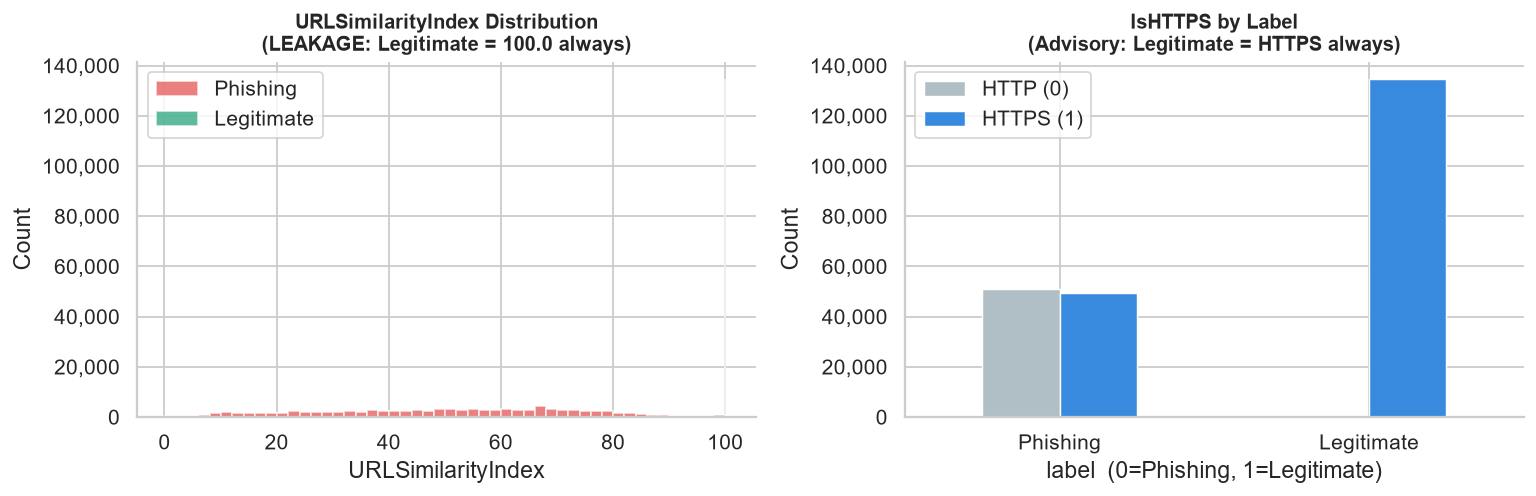

Saved → outputs/plots/eda/leakage_analysis.png


In [10]:
# Visualise leakage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: distribution by class
for label_val, color, name in [(0,'#E24B4A','Phishing'), (1,'#1D9E75','Legitimate')]:
    axes[0].hist(
        df[df[TARGET_COLUMN]==label_val]['URLSimilarityIndex'],
        bins=50, alpha=0.7, color=color, label=name, edgecolor='white'
    )
axes[0].set_title('URLSimilarityIndex Distribution\n(LEAKAGE: Legitimate = 100.0 always)',
                   fontsize=11, fontweight='600')
axes[0].set_xlabel('URLSimilarityIndex')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
sns.despine(ax=axes[0])

# Right: IsHTTPS by class
https_ct = df.groupby([TARGET_COLUMN,'IsHTTPS']).size().unstack(fill_value=0)
https_ct.plot(kind='bar', ax=axes[1], color=['#B0BEC5','#378ADD'],
              edgecolor='white', linewidth=0.8)
axes[1].set_title('IsHTTPS by Label\n(Advisory: Legitimate = HTTPS always)',
                   fontsize=11, fontweight='600')
axes[1].set_xlabel('label  (0=Phishing, 1=Legitimate)')
axes[1].set_ylabel('Count')
axes[1].legend(['HTTP (0)','HTTPS (1)'])
axes[1].set_xticklabels(['Phishing','Legitimate'], rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(PLOTS_EDA / 'leakage_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → outputs/plots/eda/leakage_analysis.png')


## 6. Full Feature Audit

In [11]:
audit_results = run_feature_audit(df, output_dir=REPORT_DIR)
audit_table   = audit_results['audit_table']

print(f'Audit table shape: {audit_table.shape}')
display(audit_table[audit_table['in_track_B']]
        [['feature','category','dtype','nunique',
          'top_value_pct','abs_r_with_label','skewness']]
        .sort_values('abs_r_with_label', ascending=False)
        .head(20))


2026-06-17 16:57:47 | INFO     | src.features.feature_catalog             | ============================================================
2026-06-17 16:57:47 | INFO     | src.features.feature_catalog             | MODULE M1.2  —  FEATURE AUDIT
2026-06-17 16:57:47 | INFO     | src.features.feature_catalog             | ============================================================
2026-06-17 16:57:47 | INFO     | src.features.feature_catalog             | Building full feature audit table …
2026-06-17 16:57:51 | INFO     | src.features.feature_catalog             | Correlation-with-target computed for 50 numeric features
2026-06-17 16:57:53 | INFO     | src.features.feature_catalog             | Variance audit: 10 near-constant features (top-value > 95% of samples)
2026-06-17 16:57:54 | INFO     | src.features.feature_catalog             | Skewness audit: 22 features with |skew| > 5
2026-06-17 16:58:10 | INFO     | src.features.feature_catalog             | Feature audit table built: 55 ro

Audit table shape: (55, 16)


,feature,category,dtype,nunique,top_value_pct,abs_r_with_label,skewness
41,HasSocialNet,Content & Trust,int64,2,54.26,0.783882,0.1710
48,HasCopyrightInfo,Content & Trust,int64,2,51.25,0.743197,0.0500
37,HasDescription,HTML Structure,int64,2,55.91,0.690011,0.2383
25,IsHTTPS,URL Structure,int64,2,78.27,0.610253,1.3711
30,DomainTitleMatchScore,HTML Structure,float64,152,48.67,0.584204,0.0121
42,HasSubmitButton,Forms & Interaction,int64,2,58.53,0.578816,0.3464
34,IsResponsive,HTML Structure,int64,2,62.49,0.548977,0.5159
24,SpacialCharRatioInURL,URL Character Composition,float64,240,4.65,0.533003,1.1874
43,HasHiddenFields,Forms & Interaction,int64,2,62.18,0.507715,0.5023
32,HasFavicon,HTML Structure,int64,2,63.78,0.493607,0.5734


## 7. Near-Constant Feature Variance Audit

In [12]:
var_stats = audit_results['variance_stats']
near_const = var_stats[var_stats['is_near_constant']].copy()

print(f'Near-constant features (top-value > 95%): {len(near_const)}')
print(near_const[['feature','nunique','top_value_pct','dtype']].to_string(index=False))


Near-constant features (top-value > 95%): 10
              feature  nunique  top_value_pct   dtype
     ObfuscationRatio      146          99.79 float64
   NoOfObfuscatedChar       20          99.79   int64
       HasObfuscation        2          99.79   int64
           IsDomainIP        2          99.73   int64
   NoOfAmpersandInURL       31          99.62   int64
      NoOfEqualsInURL       25          97.71   int64
               Crypto        2          97.65   int64
       NoOfQMarkInURL        5          97.40   int64
     NoOfSelfRedirect        2          95.99   int64
HasExternalFormSubmit        2          95.59   int64


findfont: Failed to find font weight 600, now using 700.


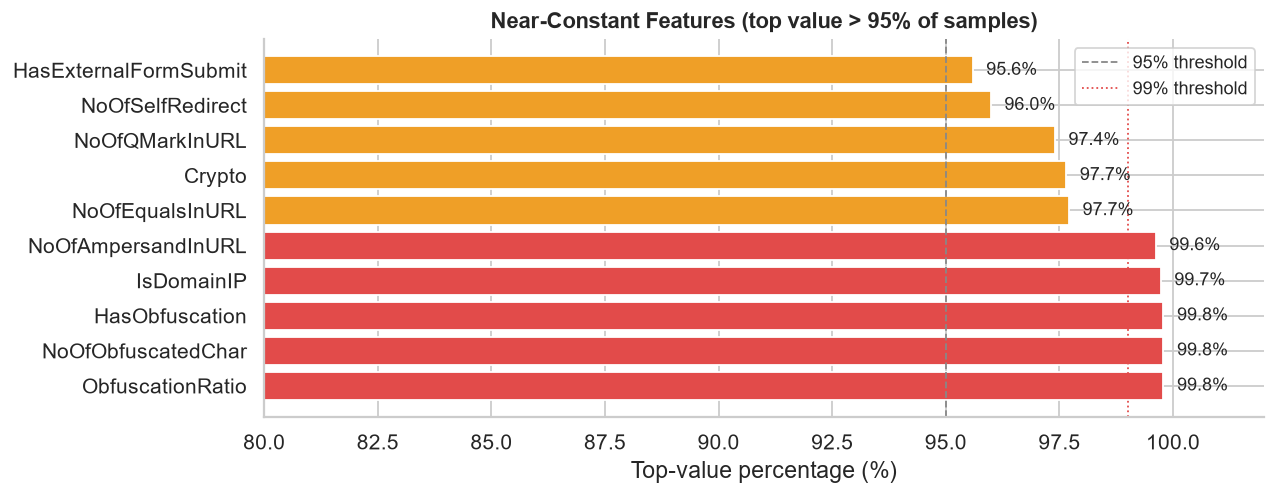

Saved → outputs/plots/eda/variance_audit.png


In [13]:
# Visualise near-constant features
nc_feats = near_const['feature'].tolist()
nc_pcts  = near_const['top_value_pct'].tolist()

if nc_feats:
    fig, ax = plt.subplots(figsize=(10, max(4, len(nc_feats)*0.38)))
    colors  = ['#E24B4A' if p > 99 else '#EF9F27' for p in nc_pcts]
    bars    = ax.barh(nc_feats, nc_pcts, color=colors, edgecolor='white')
    ax.axvline(95, color='#888', linestyle='--', linewidth=1, label='95% threshold')
    ax.axvline(99, color='#E24B4A', linestyle=':', linewidth=1, label='99% threshold')
    for bar, pct in zip(bars, nc_pcts):
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=10)
    ax.set_xlim(80, 102)
    ax.set_xlabel('Top-value percentage (%)')
    ax.set_title('Near-Constant Features (top value > 95% of samples)',
                 fontsize=12, fontweight='600')
    ax.legend(fontsize=10)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(PLOTS_EDA / 'variance_audit.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved → outputs/plots/eda/variance_audit.png')


## 8. Feature Correlation with Target Label

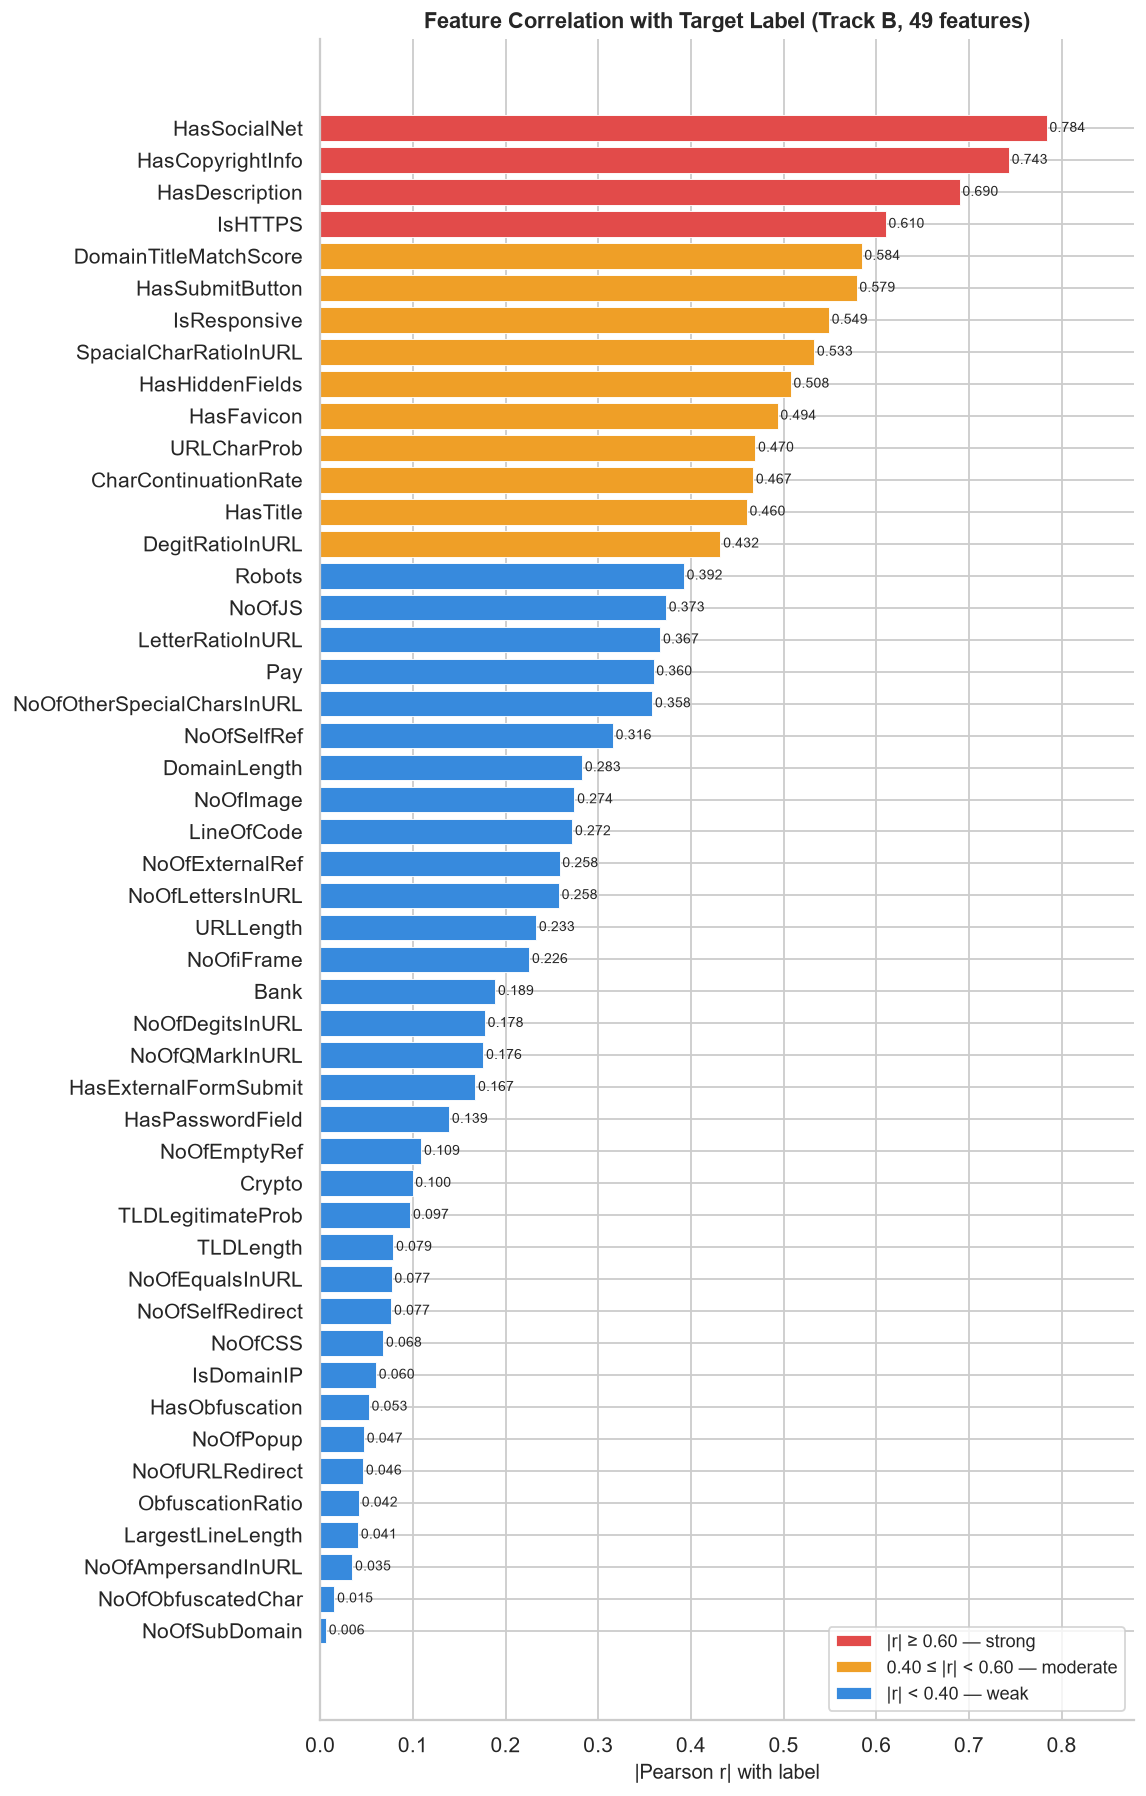

Saved → outputs/plots/eda/target_correlation.png


In [14]:
corr_target = audit_results['corr_with_target']
# Show Track B features only (exclude URLSimilarityIndex)
corr_b = corr_target[corr_target.index.isin(fl.track_B)].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 14))
colors  = ['#E24B4A' if v >= 0.6 else '#EF9F27' if v >= 0.4 else '#378ADD'
           for v in corr_b.values]
ax.barh(corr_b.index, corr_b.values, color=colors, edgecolor='white', linewidth=0.5)

# Colour legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='|r| ≥ 0.60 — strong'),
    Patch(facecolor='#EF9F27', label='0.40 ≤ |r| < 0.60 — moderate'),
    Patch(facecolor='#378ADD', label='|r| < 0.40 — weak'),
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel('|Pearson r| with label', fontsize=11)
ax.set_title('Feature Correlation with Target Label (Track B, 49 features)',
             fontsize=12, fontweight='600')
ax.set_xlim(0, max(corr_b.values)*1.12)
for v, name in zip(corr_b.values, corr_b.index):
    ax.text(v+0.003, name, f'{v:.3f}', va='center', fontsize=8)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_EDA / 'target_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → outputs/plots/eda/target_correlation.png')


## 9. Feature-Feature Correlation Heatmap

findfont: Failed to find font weight 600, now using 700.


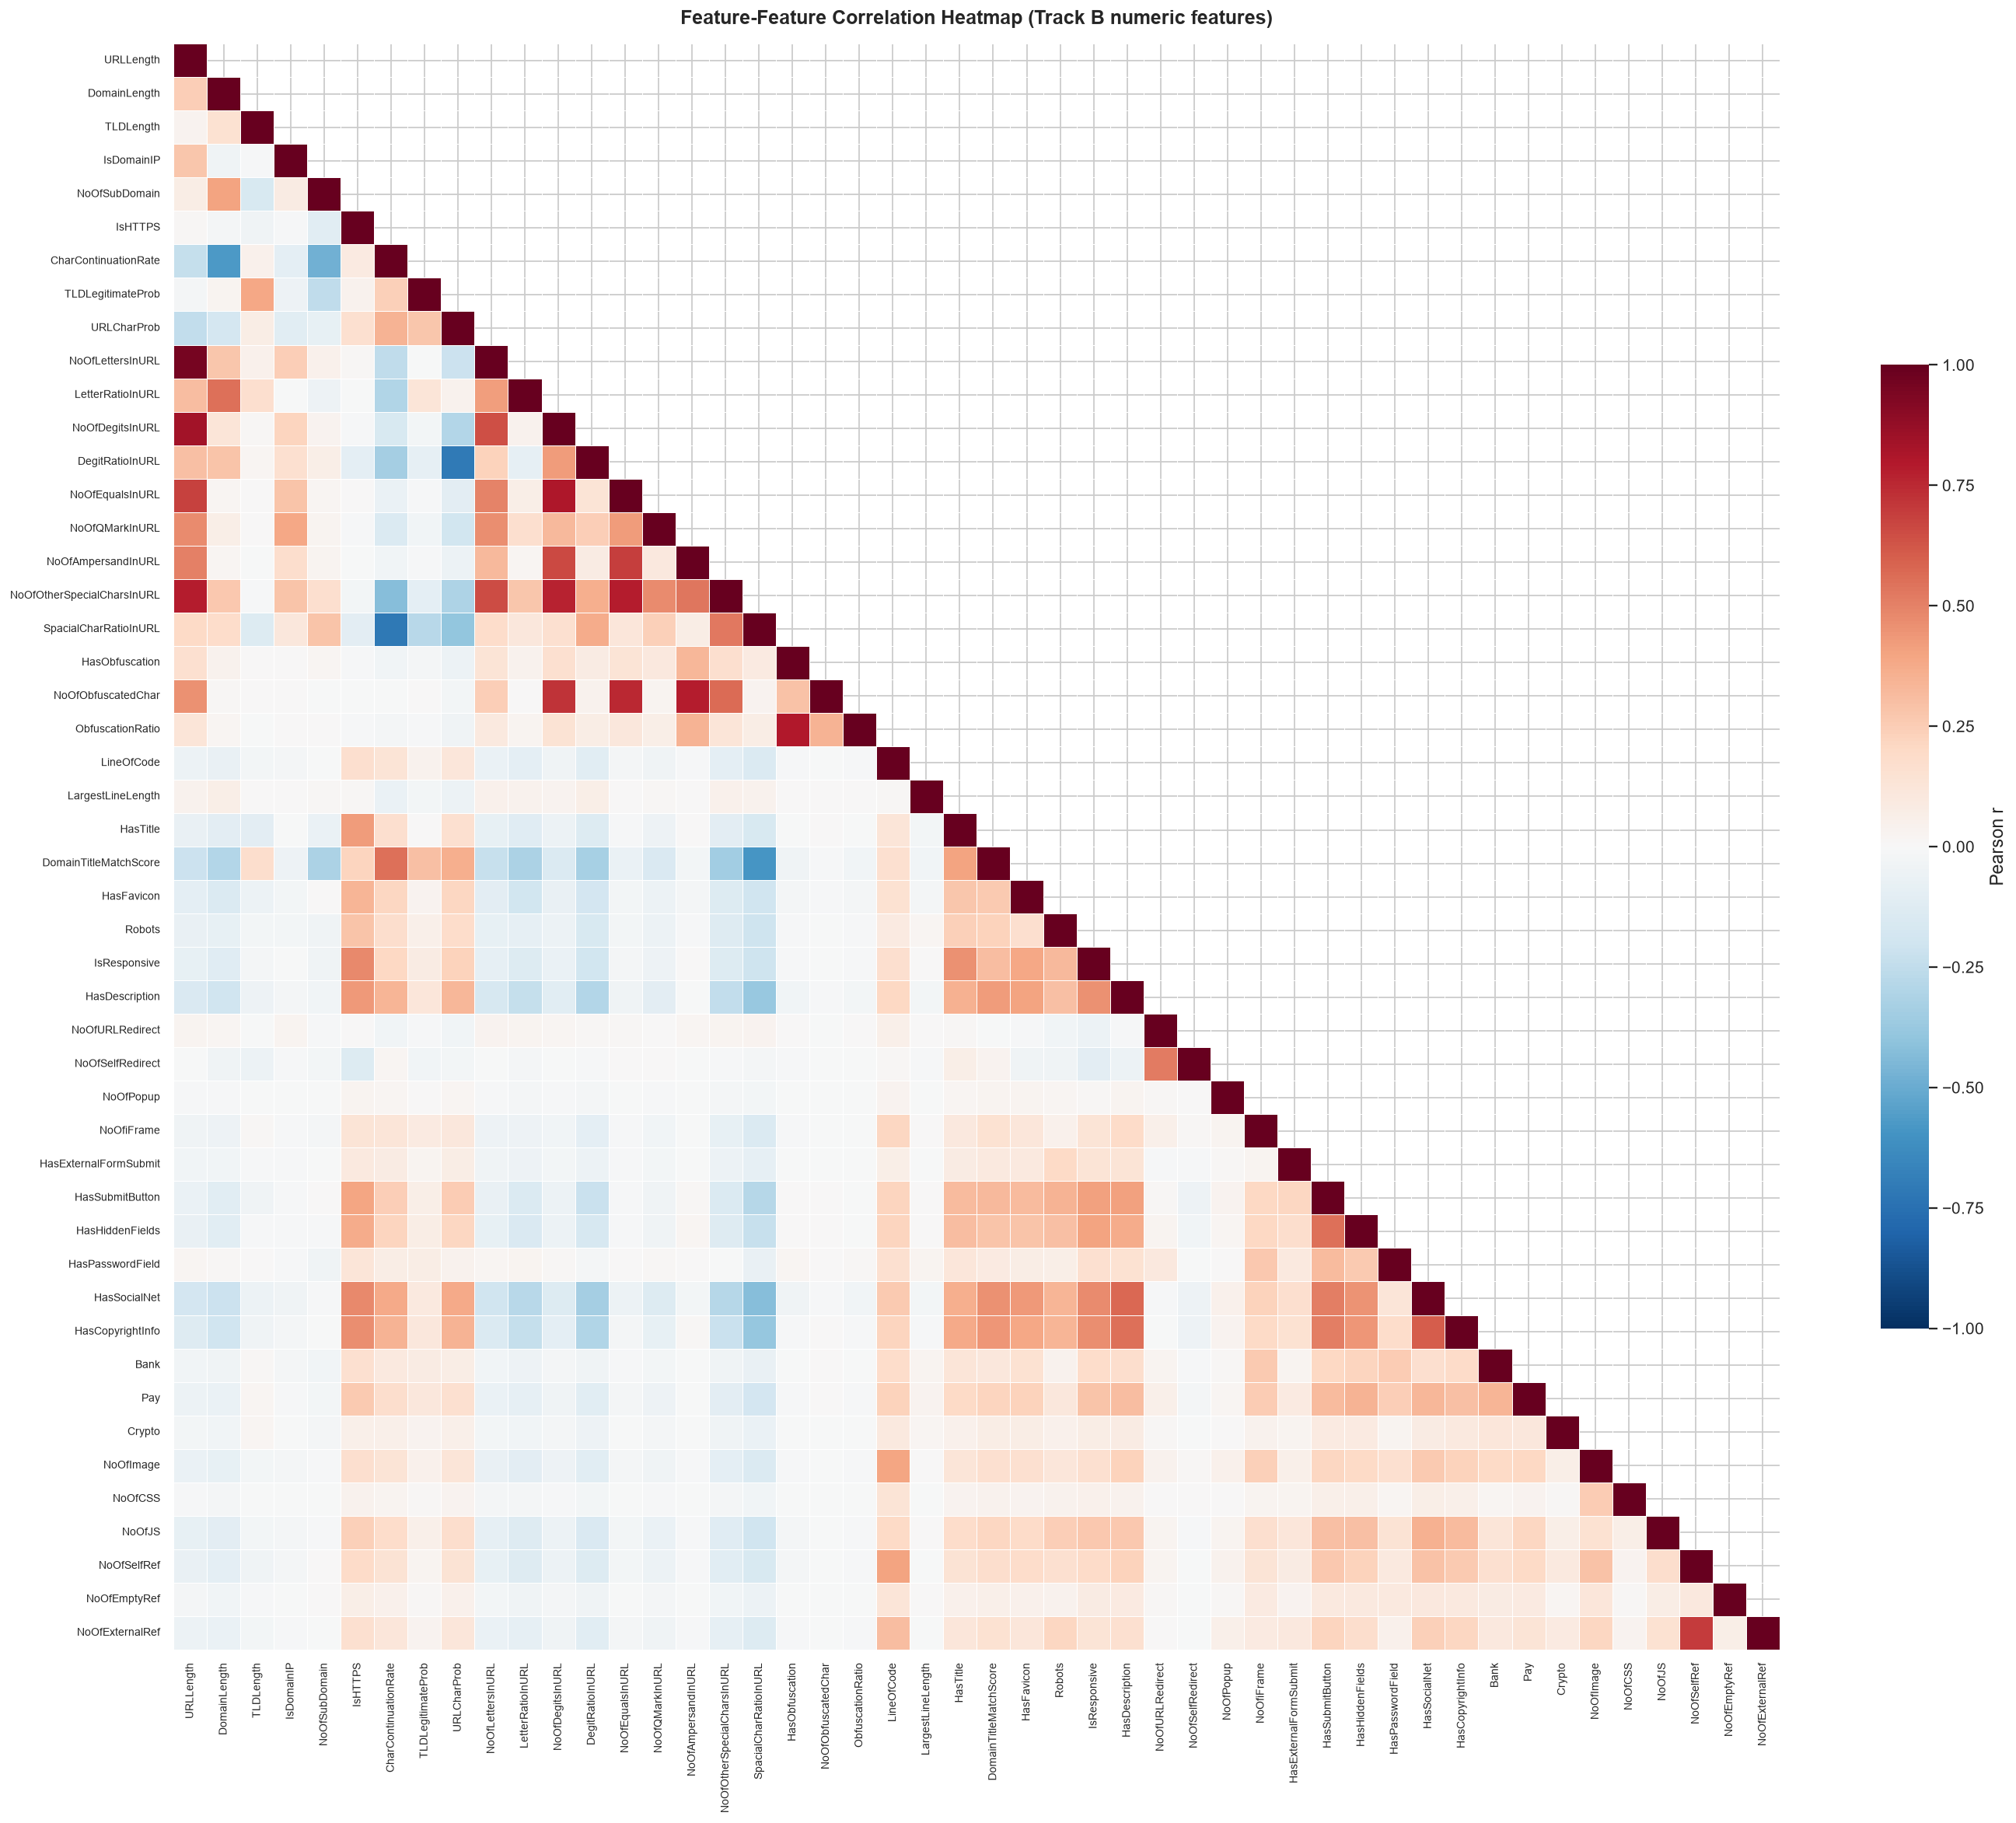

Saved → outputs/plots/eda/correlation_heatmap.png


In [15]:
num_b = [c for c in fl.track_B if df[c].dtype in ['int64','float64']]
corr_matrix = df[num_b].corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask    = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, ax=ax, mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
    annot=False,
)
ax.set_title('Feature-Feature Correlation Heatmap (Track B numeric features)',
             fontsize=14, fontweight='600', pad=14)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig(PLOTS_EDA / 'correlation_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved → outputs/plots/eda/correlation_heatmap.png')


## 10. High-Correlation Feature Pairs (|r| ≥ 0.75)

In [16]:
pairs_high   = audit_results['pairwise_high']
pairs_medium = audit_results['pairwise_medium']

print(f'High-correlation pairs (|r|≥0.75)    : {len(pairs_high)}')
print(f'Medium-correlation pairs (0.50–0.75) : {len(pairs_medium)}')

print('\nHigh-correlation pairs:')
display(pairs_high)


High-correlation pairs (|r|≥0.75)    : 9
Medium-correlation pairs (0.50–0.75) : 33

High-correlation pairs:


,feat_A,feat_B,abs_r
0,URLLength,NoOfLettersInURL,0.956046
1,URLLength,NoOfDegitsInURL,0.835966
2,NoOfDegitsInURL,NoOfEqualsInURL,0.806379
3,HasObfuscation,ObfuscationRatio,0.798787
4,NoOfObfuscatedChar,NoOfAmpersandInURL,0.786460
5,NoOfEqualsInURL,NoOfOtherSpecialCharsInURL,0.785430
6,URLLength,NoOfOtherSpecialCharsInURL,0.782596
7,NoOfDegitsInURL,NoOfOtherSpecialCharsInURL,0.767919
8,NoOfObfuscatedChar,NoOfEqualsInURL,0.754563


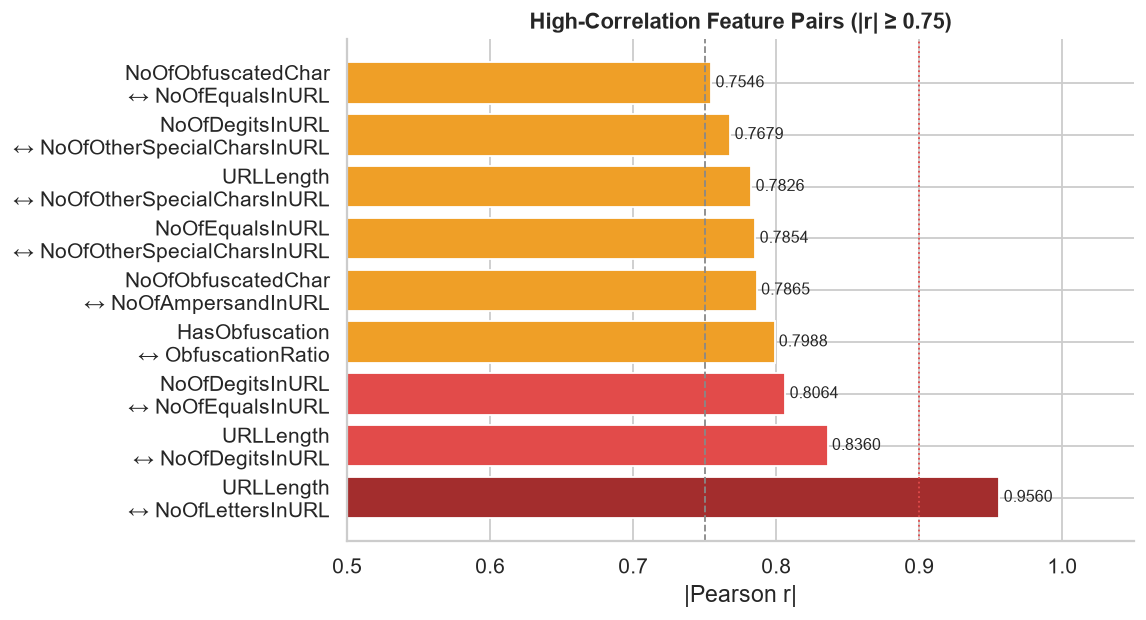

Saved → outputs/plots/eda/high_corr_pairs.png


In [17]:
if len(pairs_high) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(pairs_high)*0.55)))
    labels  = [f"{r['feat_A']}\n↔ {r['feat_B']}" for _, r in pairs_high.iterrows()]
    values  = pairs_high['abs_r'].values
    colors  = ['#A32D2D' if v>=0.9 else '#E24B4A' if v>=0.8 else '#EF9F27'
               for v in values]
    bars = ax.barh(labels, values, color=colors, edgecolor='white')
    ax.axvline(0.75, color='#888', linestyle='--', linewidth=1)
    ax.axvline(0.90, color='#E24B4A', linestyle=':', linewidth=1)
    for bar, v in zip(bars, values):
        ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)
    ax.set_xlim(0.5, 1.05)
    ax.set_xlabel('|Pearson r|')
    ax.set_title('High-Correlation Feature Pairs (|r| ≥ 0.75)',
                 fontsize=12, fontweight='600')
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(PLOTS_EDA / 'high_corr_pairs.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved → outputs/plots/eda/high_corr_pairs.png')


## 11. Feature Category Distribution

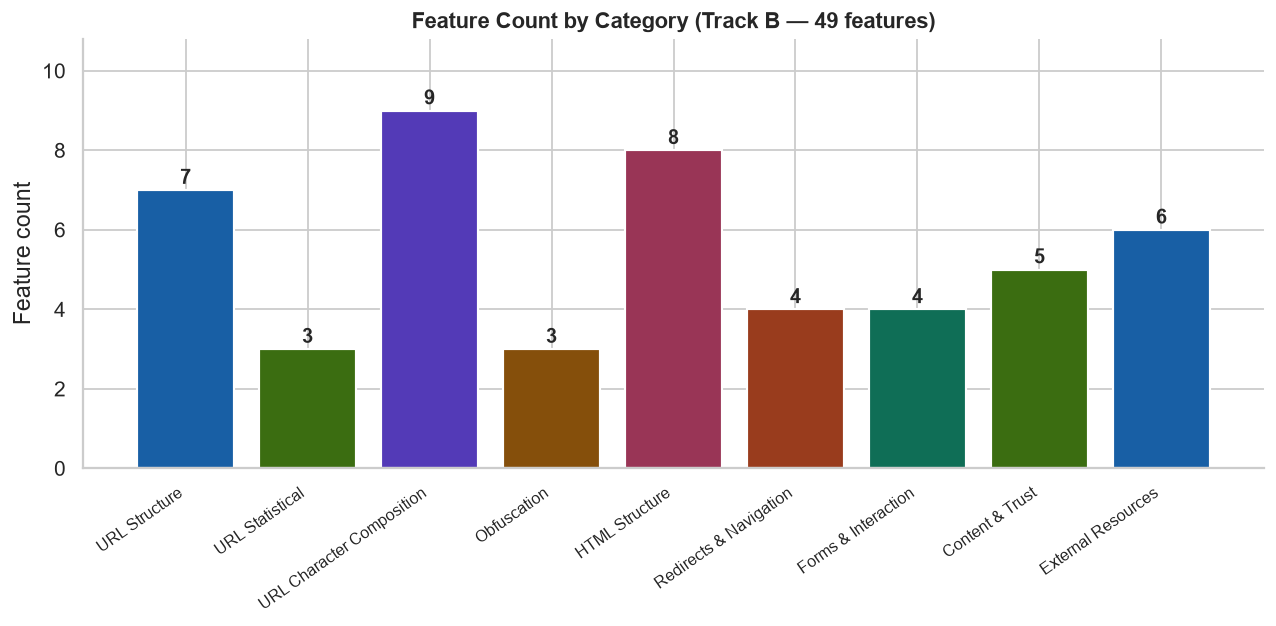

Saved → outputs/plots/eda/category_distribution.png


In [18]:
cat_counts = {cat: len(feats) for cat, feats in fl.categories.items()}
cats   = list(cat_counts.keys())
counts = list(cat_counts.values())

palette = [
    '#185FA5','#3B6D11','#533AB7','#854F0B','#993556',
    '#993C1D','#0F6E56','#3B6D11','#185FA5'
]
fig, ax = plt.subplots(figsize=(10, 5))
bars    = ax.bar(cats, counts, color=palette, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            str(cnt), ha='center', va='bottom', fontsize=11, fontweight='600')
ax.set_ylabel('Feature count')
ax.set_title('Feature Count by Category (Track B — 49 features)',
             fontsize=12, fontweight='600')
ax.set_xticklabels(cats, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, max(counts)*1.2)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_EDA / 'category_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → outputs/plots/eda/category_distribution.png')


## 12. Mutual Information Pre-Screening

In [19]:
# Use a 20k sample for speed; MI is computed on Track B numeric features
SAMPLE_N  = 20_000
rng       = np.random.default_rng(42)
idx       = rng.choice(len(df_B), size=min(SAMPLE_N, len(df_B)), replace=False)

num_b_cols = [c for c in fl.track_B
              if df_B[c].dtype in ['int64','float64'] and c != TARGET_COLUMN]
X_mi = df_B.iloc[idx][num_b_cols].fillna(0).values
y_mi = df_B.iloc[idx][TARGET_COLUMN].values

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features='auto',
                                random_state=42)
mi_series = pd.Series(mi_scores, index=num_b_cols).sort_values(ascending=False)

print(f'Mutual information computed on {min(SAMPLE_N, len(df_B)):,} samples')
print('\nTop 15 features by MI score:')
print(mi_series.head(15).to_string())


Mutual information computed on 20,000 samples

Top 15 features by MI score:
LineOfCode                    0.592129
NoOfExternalRef               0.561359
NoOfImage                     0.549694
NoOfSelfRef                   0.525199
NoOfJS                        0.498045
LargestLineLength             0.464887
NoOfCSS                       0.443686
HasSocialNet                  0.386044
LetterRatioInURL              0.385678
HasCopyrightInfo              0.323290
HasDescription                0.276992
NoOfOtherSpecialCharsInURL    0.240943
IsHTTPS                       0.223755
SpacialCharRatioInURL         0.212294
DomainTitleMatchScore         0.197787


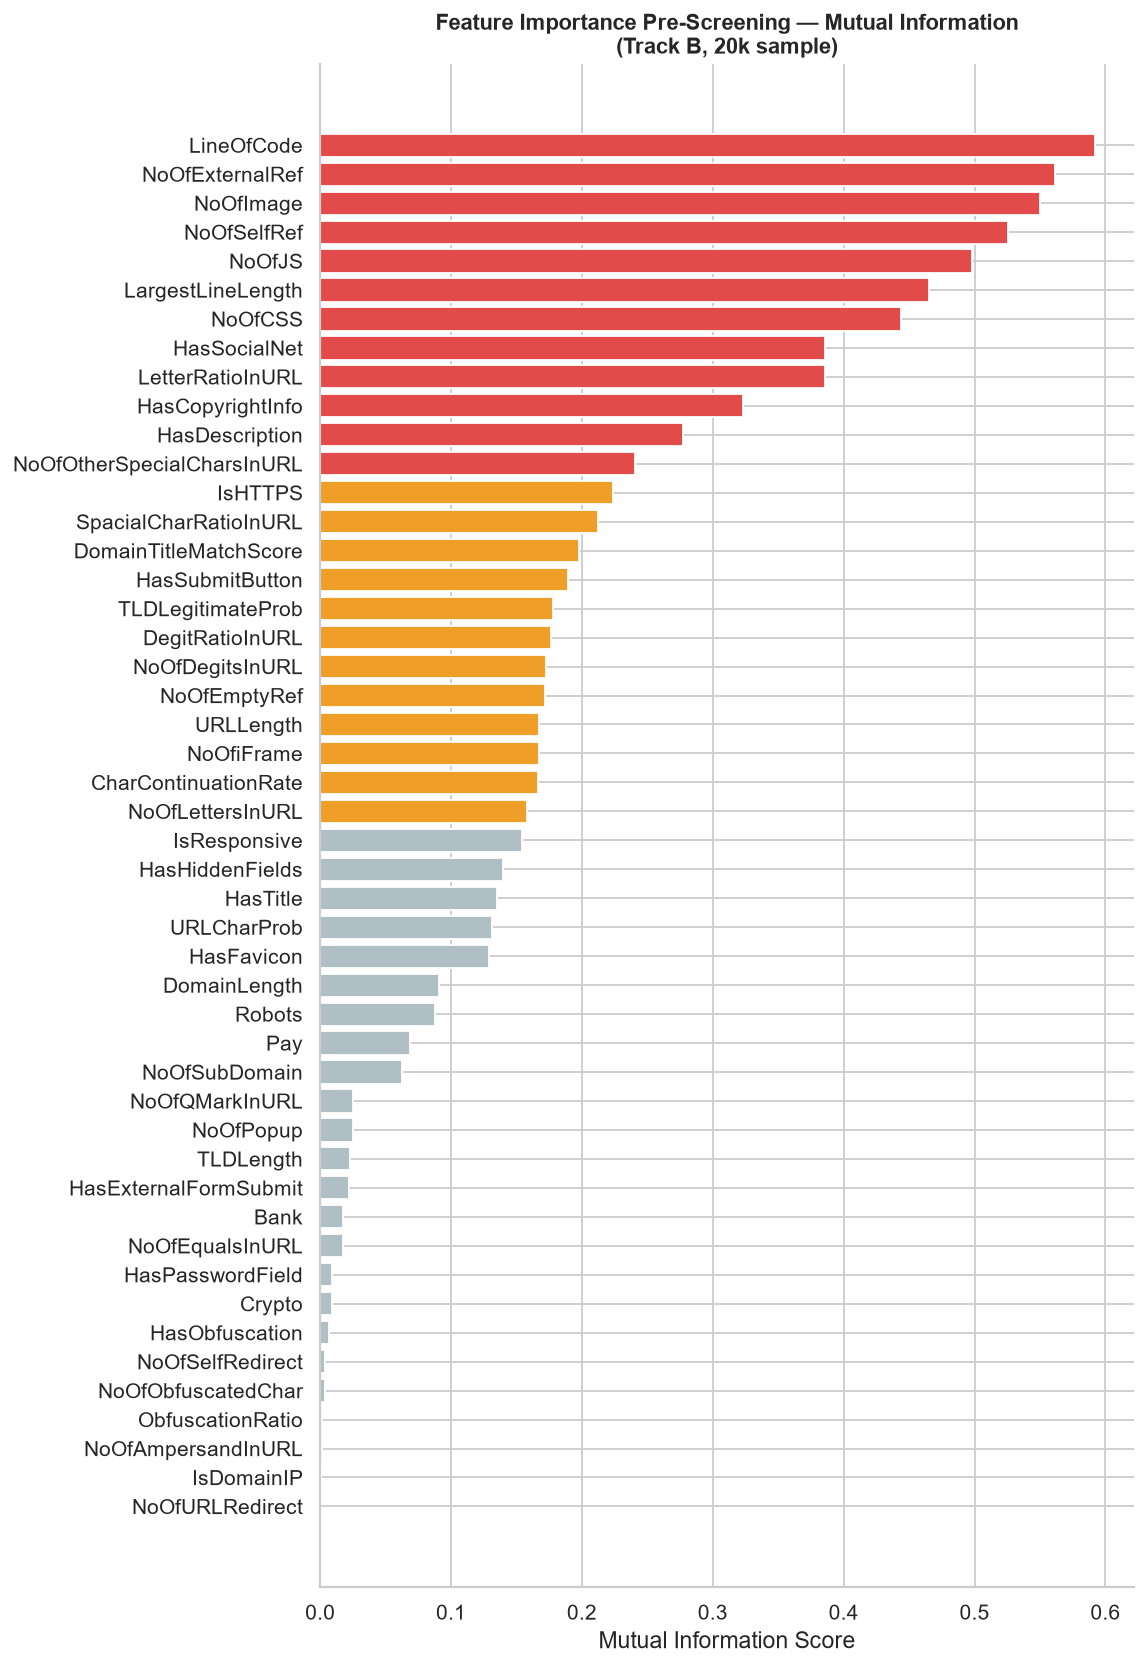

Saved → outputs/plots/eda/mutual_information.png


In [20]:
# MI bar chart
mi_plot = mi_series.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 13))
colors  = ['#E24B4A' if v >= mi_series.quantile(0.75) else
           '#EF9F27' if v >= mi_series.quantile(0.50) else '#B0BEC5'
           for v in mi_plot.values]
ax.barh(mi_plot.index, mi_plot.values, color=colors, edgecolor='white')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Importance Pre-Screening — Mutual Information\n(Track B, 20k sample)',
             fontsize=12, fontweight='600')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_EDA / 'mutual_information.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → outputs/plots/eda/mutual_information.png')


## 13. Feature List Validation

In [21]:
checks = [
    ('Track B feature count == 49',       len(fl.track_B) == 49),
    ('Track A feature count == 50',       len(fl.track_A) == 50),
    ('No duplicates in Track B',           len(set(fl.track_B)) == 49),
    ('No duplicates in Track A',           len(set(fl.track_A)) == 50),
    ('URLSimilarityIndex in Track A',      'URLSimilarityIndex' in fl.track_A),
    ('URLSimilarityIndex NOT in Track B',  'URLSimilarityIndex' not in fl.track_B),
    ('label NOT in Track A or B',          'label' not in fl.track_A),
    ('All identifiers dropped',            all(c not in fl.track_A for c in fl.drop_identifiers)),
    ('URLTitleMatchScore dropped',         'URLTitleMatchScore' not in fl.track_A),
    ('df_B has correct columns',           set(fl.track_B) == set(df_B.columns)-{'label'}),
    ('df_A has correct columns',           set(fl.track_A) == set(df_A.columns)-{'label'}),
]

all_pass = True
for desc, result in checks:
    status = '✓ PASS' if result else '✗ FAIL'
    if not result:
        all_pass = False
    print(f'  {status}  {desc}')

print()
if all_pass:
    print('ALL VALIDATION CHECKS PASSED ✓')
else:
    raise AssertionError('One or more validation checks FAILED — review feature catalog')


  ✓ PASS  Track B feature count == 49
  ✓ PASS  Track A feature count == 50
  ✓ PASS  No duplicates in Track B
  ✓ PASS  No duplicates in Track A
  ✓ PASS  URLSimilarityIndex in Track A
  ✓ PASS  URLSimilarityIndex NOT in Track B
  ✓ PASS  label NOT in Track A or B
  ✓ PASS  All identifiers dropped
  ✓ PASS  URLTitleMatchScore dropped
  ✓ PASS  df_B has correct columns
  ✓ PASS  df_A has correct columns

ALL VALIDATION CHECKS PASSED ✓


## 14. Save Processed DataFrames (Track A & B)

In [22]:
track_A_path = PROJECT_ROOT / 'data' / 'processed' / 'track_A' / 'features_full.csv'
track_B_path = PROJECT_ROOT / 'data' / 'processed' / 'track_B' / 'features_full.csv'

track_A_path.parent.mkdir(parents=True, exist_ok=True)
track_B_path.parent.mkdir(parents=True, exist_ok=True)

df_A.to_csv(track_A_path, index=False)
df_B.to_csv(track_B_path, index=False)

print(f'Saved Track A: {track_A_path}  ({df_A.shape})')
print(f'Saved Track B: {track_B_path}  ({df_B.shape})')


Saved Track A: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\data\processed\track_A\features_full.csv  ((235370, 51))
Saved Track B: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\data\processed\track_B\features_full.csv  ((235370, 50))


## 15. Generate HTML Report

In [23]:
report_path = generate_report(
    df_clean     = df,
    audit_results= audit_results,
    output_path  = REPORT_DIR / 'm1_2_feature_finalization_report.html',
    plots_dir    = PLOTS_EDA,
)
print(f'Report saved: {report_path}')


2026-06-17 16:59:35 | INFO     | src.features.report_m1_2                 | M1.2 HTML report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\m1_2_feature_finalization_report.html


Report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\m1_2_feature_finalization_report.html


## 16. M1.2 Summary

In [24]:
summary = {
    'raw_columns'           : 56,
    'identifiers_dropped'   : len(fl.drop_identifiers),
    'multicollinear_dropped': len(fl.drop_multicollinear),
    'leakage_critical'      : fl.leakage_critical,
    'leakage_advisory'      : fl.leakage_advisory,
    'track_A_features'      : len(fl.track_A),
    'track_B_features'      : len(fl.track_B),
    'high_corr_pairs'       : len(pairs_high),
    'near_constant_features': int(audit_results['variance_stats']['is_near_constant'].sum()),
    'plots_saved'           : list(PLOTS_EDA.glob('*.png')).__len__(),
    'report_path'           : report_path,
}

print('=' * 58)
print('MODULE M1.2 COMPLETE')
print('=' * 58)
for k, v in summary.items():
    print(f'  {k:<30}: {v}')
print('=' * 58)
print('This feature list is the single source of truth for the')
print('entire project. Next step: M2.1 — Exploratory Data Analysis')


MODULE M1.2 COMPLETE
  raw_columns                   : 56
  identifiers_dropped           : 4
  multicollinear_dropped        : 1
  leakage_critical              : ['URLSimilarityIndex']
  leakage_advisory              : ['IsHTTPS']
  track_A_features              : 50
  track_B_features              : 49
  high_corr_pairs               : 9
  near_constant_features        : 10
  plots_saved                   : 9
  report_path                   : C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\m1_2_feature_finalization_report.html
This feature list is the single source of truth for the
entire project. Next step: M2.1 — Exploratory Data Analysis
